# V3.7 — Surface reflectance grounding  **TIER 3 / appearance constants**

**Claim (pre-registered).** The derived appearance map (`nebula.geometry.appearance`) lands its material endpoints in **measured reflectance ranges** (char ≈ soot-black, ash pale-grey, wet darkening) and its ember emission follows **blackbody T⁴** — the appearance is a derived simulation output, but its constants are grounded, not invented.

**Independent oracle.** `reflectance_ref.py` — representative diffuse-reflectance ranges + the wet-darkening factor + the Stefan–Boltzmann emission scaling.

| # | Metric | Threshold |
|---|---|---|
| C1 | char albedo luminance in measured char range | ∈ [0.02, 0.06] |
| C2 | ash albedo luminance in measured ash range | ∈ [0.22, 0.45] |
| C3 | wet-darkening factor in measured range | ∈ [0.45, 0.75] |
| C4 | ember emission scales as T⁴ (Stefan–Boltzmann) | ratio(1600/800) = 16 |
| C5 | derived ordering: char ≪ bark ≪ fresh wood luminance | strictly increasing |

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.geometry import appearance as ap
import reflectance_ref as rr
np.seterr(all='ignore')
R = {}
lum = rr.luminance
R['C1_char'] = lum(ap.CHAR_ALBEDO); R['C2_ash'] = lum(ap.ASH_ALBEDO); R['C3_wet'] = ap.WET_DARKEN
R['C4_ratio'] = float(ap.emission_intensity(1600, T_on=0, T_full=3000)/ap.emission_intensity(800, T_on=0, T_full=3000))
bark = ap.surface_appearance(np.array([0.40,0.26,0.13]))['albedo']
char = ap.surface_appearance(np.array([0.40,0.26,0.13]), chi=1.0)['albedo']
fresh = ap.surface_appearance(np.array([0.5,0.42,0.30]))['albedo']
R['C5_order'] = bool(lum(char) < lum(bark) < lum(fresh))
print(f"C1 char luminance {R['C1_char']:.3f} in [0.02,0.06]: {rr.in_range(R['C1_char'],'char')}")
print(f"C2 ash luminance {R['C2_ash']:.3f} in [0.22,0.45]: {rr.in_range(R['C2_ash'],'ash')}")
print(f"C3 wet-darken {R['C3_wet']:.2f} in [0.45,0.75]: {rr.WET_DARKEN_RANGE[0]<=R['C3_wet']<=rr.WET_DARKEN_RANGE[1]}")
print(f"C4 emission T^4 ratio {R['C4_ratio']:.1f} (=16)")
print(f"C5 ordering char {lum(char):.3f} < bark {lum(bark):.3f} < fresh {lum(fresh):.3f}: {R['C5_order']}")

C1 char luminance 0.036 in [0.02,0.06]: True
C2 ash luminance 0.303 in [0.22,0.45]: True
C3 wet-darken 0.55 in [0.45,0.75]: True
C4 emission T^4 ratio 16.0 (=16)
C5 ordering char 0.036 < bark 0.280 < fresh 0.428: True


saved results/V3_7_reflectance.png

V3.7 PASS — appearance constants land in measured reflectance ranges; emission is blackbody T⁴.


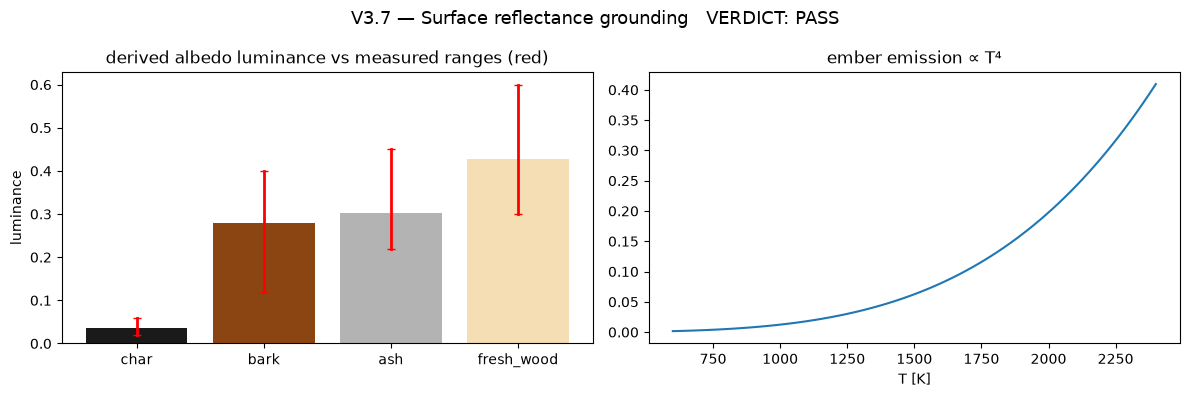

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
names = ['char','bark','ash','fresh_wood']; vals = [R['C1_char'], lum(bark), R['C2_ash'], lum(fresh)]
ax[0].bar(names, vals, color=['0.1','saddlebrown','0.7','wheat'])
for k,(lo,hi) in rr.ALBEDO_RANGES.items():
    x = names.index(k) if k in names else None
    if x is not None: ax[0].plot([x,x],[lo,hi],'r_-',lw=2)
ax[0].set_title('derived albedo luminance vs measured ranges (red)'); ax[0].set_ylabel('luminance')
T = np.linspace(600,2400,80); ax[1].plot(T, ap.emission_intensity(T,T_on=0,T_full=3000)); ax[1].set_title('ember emission ∝ T⁴'); ax[1].set_xlabel('T [K]')
C1=rr.in_range(R['C1_char'],'char'); C2=rr.in_range(R['C2_ash'],'ash'); C3=rr.WET_DARKEN_RANGE[0]<=R['C3_wet']<=rr.WET_DARKEN_RANGE[1]; C4=abs(R['C4_ratio']-16)<1e-6; C5=R['C5_order']
allpass=C1 and C2 and C3 and C4 and C5
fig.suptitle(f'V3.7 — Surface reflectance grounding   VERDICT: {"PASS" if allpass else "FAIL"}', fontsize=13)
fig.tight_layout(); fig.savefig('results/V3_7_reflectance.png', dpi=110, bbox_inches='tight')
print('saved results/V3_7_reflectance.png')
assert allpass, 'V3.7 criteria not all met'
print('\nV3.7 PASS — appearance constants land in measured reflectance ranges; emission is blackbody T⁴.')